In [1]:
DATA = '../data/'
FIGS = '../results/figures/'
CACHE = '../f1_cache'

In [2]:
import pandas as pd

# 1. Load the pickle file into a pandas DataFrame
df = pd.read_pickle(DATA + 'laps_raw.pkl')

# 2. Convert and save the DataFrame as a CSV file
df.to_csv(DATA + 'laps_raw.csv', index=False)

In [3]:
df.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'AirTemp', 'TrackTemp', 'Year',
       'Round', 'Circuit'],
      dtype='object')

In [4]:
import pandas as pd

raw = pd.read_pickle(DATA + 'laps_raw.pkl') # select the raw lap data file to read

# LOOK BEFORE YOU FILTER. Compound naming varies by season - confirm what you are dropping
print(raw['Compound'].value_counts(dropna=False), "\n")
print("TrackStatus dtype:", raw['TrackStatus'].dtype, "\n") # must be object/string, or the '1' test silently matches nothing

# Circuit comes from ev['Location'], an upstream string. If FastF1 renames one between
# seasons, one track becomes two labels, and each half may be too thin to survive the split.
yrs = raw.groupby('Circuit')['Year'].nunique()
print("circuits missing from some seasons:\n", yrs[yrs < raw['Year'].nunique()], "\n")

# clean the data to only keep laps that are:
df = raw[
    raw['IsAccurate'] & # actual racing laps unaffected by pit lane etc
    (raw['TrackStatus'] == '1') & # laps raced under the green flag
    raw['LapTime'].notna() & # have available lap times data
    raw['Compound'].notna() & # have available compounds data
    raw['TyreLife'].notna() # have available tyre life data
].copy()

# 'None' here is the literal string, not a missing value, so .notna() above lets it through.
df = df[~df['Compound'].isin(['INTERMEDIATE', 'WET', 'None'])].copy() # .copy() or the relabel below warns
df['LapSeconds'] = df['LapTime'].dt.total_seconds()

# Circuits whose LAYOUT changed inside the training window: same label, two different tracks.
LAYOUT_CHANGED = [
    (2022, 'Barcelona'), # final chicane removed for 2023
    (2022, 'Marina Bay'), # turns 16-19 replaced by a straight for 2023
]

# Rename any track layout inside LAYOUT_CHANGED so model can't read it
# removes it from training, but doesn't delete it
for yr, ckt in LAYOUT_CHANGED:
    m = (df['Year'] == yr) & (df['Circuit'] == ckt)
    df.loc[m, 'Circuit'] = f'{ckt}_pre{yr + 1}'
    print(f"relabelled {m.sum()} laps: {ckt} {yr} -> {ckt}_pre{yr + 1}")

# LOOK BEFORE YOU CUT. Each lap's time as a fraction of that driver's race median.
# RaceID does not exist yet, so group on Year/Round. Where 'median' stops falling is
# where the field settled; 'count' shows what the filters above already removed.
rel = df['LapSeconds'] / df.groupby(['Year', 'Round', 'Driver'])['LapSeconds'].transform('median')
print(pd.DataFrame({'rel': rel, 'lap': df['LapNumber']})
      .query('lap <= 12').groupby('lap')['rel'].agg(['median', 'count']).round(4), "\n")

# Same reading, by TYRE age instead of race lap. IsAccurate removes the out-lap but NOT the
# first flying lap after it - cold tyres and traffic from the stop, sitting at low TyreLife.
# Those laps flatten the degradation slope, and SOFT takes the worst of it because its
# stints are short, so a bigger share of its laps live down here.
print(pd.DataFrame({'rel': rel, 'age': df['TyreLife']})
      .query('age <= 10').groupby('age')['rel'].agg(['median', 'count']).round(4), "\n")

# Set this from the table above: the first tyre age whose median has stopped falling.
TYRE_SETTLE = 2
before = len(df)
df = df[df['TyreLife'] > TYRE_SETTLE]
print(f"tyre-settle cut: {before - len(df)} laps removed ({(before - len(df)) / before:.1%})")

df['RaceID'] = df['Year'].astype(str) + '_' + df['Round'].astype(str)

# Compound affects lap time through DEGRADATION RATE, not pace - measured, see Step 6.
# A linear model cannot express that without these columns, and the trees did not find
# them on their own. Built here so they reach Step 8's CSV as real features.
df['SoftAge'] = (df['Compound'] == 'SOFT') * df['TyreLife']
df['MedAge'] = (df['Compound'] == 'MEDIUM') * df['TyreLife']

df['TeamYear'] = df['Team'] + '_' + df['Year'].astype(str)

cols = ['LapSeconds', 'TyreLife', 'LapNumber', 'Compound', 'Circuit',
        'Driver', 'Team', 'AirTemp', 'TrackTemp', 'FreshTyre',
        'SoftAge', 'MedAge', 'RaceID', 'Year', 'Round', 'TeamYear']

# dropna() below kills a row if ANY of these 15 columns is missing.
# A failed weather join makes AirTemp/TrackTemp NaN for a whole race, which would
# delete that race silently. Look at what is missing BEFORE dropping it.
print("nulls per column:\n", df[cols].isna().sum()[lambda x: x > 0], "\n")

races_before = df['RaceID'].nunique()
df = df[cols].dropna()
races_after = df['RaceID'].nunique()

# A race with very few surviving laps was wet or red-flagged. Its survivors are the
# least-bad laps of a bad race, not clean laps. Look at the distribution before you pick 400.
laps_per_race = df.groupby('RaceID')['LapSeconds'].size()
print("thinnest races:\n", laps_per_race.sort_values().head(8), "\n")
thin = laps_per_race[laps_per_race < 400].index.tolist()
print("dropping thin races:", thin)
df = df[~df['RaceID'].isin(thin)]

# A circuit with one season cannot be both trained on and tested. Thin races go first,
# because dropping one can leave a circuit with a single remaining season.
seasons = df.groupby('Circuit')['Year'].nunique()
solo = seasons[seasons < 2].index.tolist()
print("dropping single-season circuits:", solo)
df = df[~df['Circuit'].isin(solo)]

# A race can lose every lap to the filters above and so appear in neither list.
gone = sorted(set(raw['Year'].astype(str) + '_' + raw['Round'].astype(str)) - set(df['RaceID']))
print(f"{len(gone)} races have no surviving laps:", gone)

# One tyre-age column per circuit. A linear model has no interaction term, so without these
# it fits ONE degradation slope for every track - and that global slope is about half
# Barcelona's true value, which would make the simulator recommend stints that are too long.
# Built HERE, after the circuit drops, so only surviving circuits get a column and so the
# columns reach Step 8's CSV as real features. Create ML cannot build them for you.
for c in sorted(df['Circuit'].unique()):
    df[f'age_{c}'] = (df['Circuit'] == c) * df['TyreLife']
print(f"built {df.columns.str.startswith('age_').sum()} per-circuit tyre-age columns")

for c in sorted(df['Circuit'].unique()):
    df[f'fuel_{c}'] = (df['Circuit'] == c) * df['LapNumber']

# Compound degradation differs BY CIRCUIT. SOFT measured +0.011 s/lap steeper than HARD at
# Barcelona, but flat once averaged over every track - so a global SoftAge term reads zero.
# Two more columns, demo circuit only. These decide whether the compound selector does
# anything at all, so they are a UI decision as much as a modelling one.
DEMO_CIRCUIT = 'Barcelona'
at_demo = df['Circuit'] == DEMO_CIRCUIT
df['age_demo_soft'] = (at_demo & (df['Compound'] == 'SOFT')) * df['TyreLife']
df['age_demo_med'] = (at_demo & (df['Compound'] == 'MEDIUM')) * df['TyreLife']
print(f"{DEMO_CIRCUIT}: {int(at_demo.sum())} laps get their own compound slopes")

df.to_pickle(DATA + 'laps_clean.pkl')
print(f"{len(raw)} raw -> {len(df)} clean ({len(df)/len(raw):.0%} kept)")
print(f"races: {races_before} -> {races_after}")
if races_after < races_before:
    print("WARNING: dropna() removed whole races. Check the nulls above before continuing.")
print(df['Compound'].value_counts())

Compound
HARD            44357
MEDIUM          36901
SOFT            12761
INTERMEDIATE     5945
WET               461
nan               446
None              426
Name: count, dtype: int64 

TrackStatus dtype: object 

circuits missing from some seasons:
 Circuit
Imola            3
Las Vegas        3
Le Castellet     1
Lusail           3
Miami            3
Miami Gardens    1
Shanghai         2
Name: Year, dtype: int64 

relabelled 1060 laps: Barcelona 2022 -> Barcelona_pre2023
relabelled 275 laps: Marina Bay 2022 -> Marina Bay_pre2023
      median  count
lap                
2.0   1.0177   1050
3.0   1.0109   1125
4.0   1.0100   1302
5.0   1.0096   1401
6.0   1.0092   1368
7.0   1.0088   1341
8.0   1.0095   1341
9.0   1.0084   1351
10.0  1.0090   1333
11.0  1.0091   1360
12.0  1.0086   1340 

      median  count
age                
1.0   1.0131     14
2.0   1.0012   2687
3.0   1.0011   3027
4.0   1.0012   3219
5.0   1.0014   3542
6.0   1.0011   3543
7.0   1.0011   3553
8.0   1.0011   35

/var/folders/sj/skx1mhmd28960x609gz911f80000gn/T/ipykernel_77304/1295701933.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RaceID'] = df['Year'].astype(str) + '_' + df['Round'].astype(str)
/var/folders/sj/skx1mhmd28960x609gz911f80000gn/T/ipykernel_77304/1295701933.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SoftAge'] = (df['Compound'] == 'SOFT') * df['TyreLife']
/var/folders/sj/skx1mhmd28960x609gz911f80000gn/T/ipykernel_77304/1295701933.py:66: SettingWithCopyWarning: 
A value is tryin

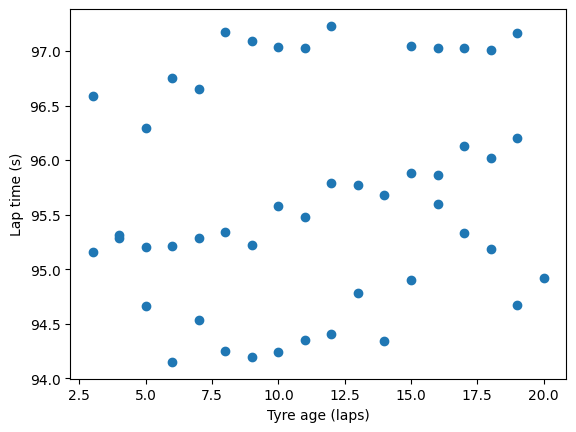

In [5]:
import matplotlib.pyplot as plt

stint = df[(df['RaceID'] == '2024_1') & (df['Driver'] == 'VER')]
assert len(stint) > 0, "no laps matched - pick a RaceID and Driver that exist in df"
plt.scatter(stint['TyreLife'], stint['LapSeconds'])
plt.xlabel('Tyre age (laps)'); plt.ylabel('Lap time (s)')
plt.show()

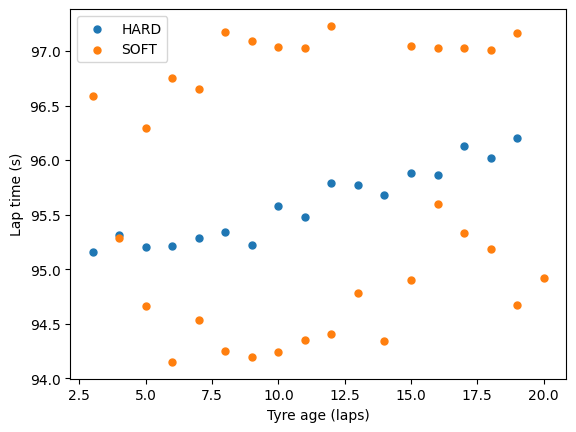

In [6]:
for c, g in stint.groupby('Compound'):
    plt.scatter(g['TyreLife'], g['LapSeconds'], label=c, s=25)
plt.xlabel('Tyre age (laps)'); plt.ylabel('Lap time (s)'); plt.legend()
plt.show()

In [7]:
med = df.groupby(['Circuit', 'Year'])['LapSeconds'].median().unstack()
delta = med.diff(axis=1)           # each circuit's change from the previous year
trend = delta.median()             # what every circuit did that year - regulations, tyres
anomaly = delta.sub(trend, axis=1) # what THIS circuit did beyond that

print("Lap time change beyond the season-wide trend (seconds):")
print(anomaly.round(1).dropna(how='all').to_string())

flagged = anomaly[anomaly.abs() > 1.5].stack() # 1.5s is a starting point, not a rule
if len(flagged):
    print("\nWorth investigating:\n", flagged.round(1).to_string())

Lap time change beyond the season-wide trend (seconds):
Year               2022  2023  2024  2025
Circuit                                  
Austin              NaN   0.2  -1.6   0.3
Baku                NaN  -1.5   2.4  -2.5
Barcelona           NaN   NaN   1.1   0.8
Budapest            NaN   0.8   0.4  -1.7
Imola               NaN   NaN   NaN   0.0
Jeddah              NaN   0.9  -0.5   0.8
Las Vegas           NaN   NaN   0.3  -1.9
Lusail              NaN   NaN  -1.5   0.4
Marina Bay          NaN   NaN  -1.3  -0.2
Melbourne           NaN  -0.9   0.6   NaN
Mexico City         NaN   0.8  -1.2   1.0
Miami               NaN  -1.1   0.9   NaN
Monaco              NaN   0.8   1.6  -1.9
Montréal            NaN  -0.4   NaN   NaN
Monza               NaN   0.8  -1.5  -0.9
Sakhir              NaN   0.0  -0.9   2.0
Shanghai            NaN   NaN   NaN  -3.5
Silverstone         NaN  -0.0  -0.1   NaN
Spa-Francorchamps   NaN  -0.5  -3.3  -1.1
Spielberg           NaN  -0.0   1.3   0.0
Suzuka              